In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.mast import Observations, Mast
from pprint import pprint
import os

mast = Mast()

target_name = "M42"
search_radius = "0.1 deg"

obs = Observations.query_object(target_name, radius=search_radius)

print(f"MAST rows within {search_radius} of {target_name!r}: {len(obs)}")

if len(obs) == 0:
    raise RuntimeError(
        "No observations returned. Check the target name, your network connection, "
        "and try a larger search_radius (e.g. '0.5 deg')."
    )

miri_obs = obs[
    (obs["instrument_name"] == "MIRI/IMAGE")
    & (obs["dataproduct_type"] == "image")
    & (obs["obs_collection"] == "JWST")
    & (obs["dataRights"] == "PUBLIC")
]

print(
    "After JWST / MIRI/IMAGE / image / PUBLIC filter:",
    len(miri_obs),
)

if len(miri_obs) == 0:
    jwst = obs[obs["obs_collection"] == "JWST"]
    print(f"JWST rows in this cone (any instrument/products): {len(jwst)}")
    if len(jwst) > 0:
        inst = sorted({str(x) for x in jwst["instrument_name"].tolist()})
        preview = inst[:15]
        suffix = " ..." if len(inst) > len(preview) else ""
        print("instrument_name values on those JWST rows:", preview, suffix)
    raise RuntimeError(
        "No JWST MIRI imaging (PUBLIC) matched your filters. "
        "Try another target (e.g. M42), increase search_radius, or relax filters in the next cell."
    )


MAST rows within 0.1 deg of 'M42': 16071
After JWST / MIRI/IMAGE / image / PUBLIC filter: 10


In [2]:
miri_obs

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,wave_min,wave_max,distance
str11,str4,str31,str13,str12,str27,str19,str64,str95,str90,float64,float64,str10,str32,int64,float64,float64,float64,str19,float64,float64,str132,float64,str23,str12,int64,str54874,str178,str179,str16,bool,float64,str9,float64,float64,float64
science,JWST,CALJWST,MIRI/IMAGE,JWST,F770W,INFRARED,ORIBAR-IMAGING-MIRI,ISM; Dense interstellar clouds; Dust nebulae; Molecular gas; Nebulae; Photodissociation regions,jw01288-o015_t012_miri_f770w-sub128,83.83477,-5.4177805555555665,image,"Berne, Olivier",3,59840.69218439815,59840.843635034726,2214.513000000001,INFRARED,6600.0,8800.0,Radiative Feedback from Massive Stars as Traced by Multiband Imaging and Spectroscopic Mosaics,59841.18049767,1288,ERS,--,POLYGON 83.840185364 -5.423956619 83.828675753 -5.423313474 83.829344227 -5.411459238 83.840853613 -5.412102372,mast:JWST/product/jw01288-o015_t012_miri_f770w-sub128_i2d.jpg,mast:JWST/product/jw01288-o015_t012_miri_f770w-sub128_i2d.fits,PUBLIC,False,nan,93456034,6600.0,8800.0,92.06168044927627
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1130W,INFRARED,ORIBAR-IMAGING-MIRI,ISM; Dense interstellar clouds; Dust nebulae; Molecular gas; Nebulae; Photodissociation regions,jw01288-o015_t012_miri_f1130w-sub128,83.83477,-5.4177805555555665,image,"Berne, Olivier",3,59840.70134439815,59840.85289354167,2214.513000000001,INFRARED,10950.0,11650.0,Radiative Feedback from Massive Stars as Traced by Multiband Imaging and Spectroscopic Mosaics,59841.18049767,1288,ERS,--,POLYGON 83.840203279 -5.423962178 83.828693668 -5.423319012 83.829362163 -5.411464778 83.840871549 -5.412107931,mast:JWST/product/jw01288-o015_t012_miri_f1130w-sub128_i2d.jpg,mast:JWST/product/jw01288-o015_t012_miri_f1130w-sub128_i2d.fits,PUBLIC,False,nan,93455806,10950.0,11650.0,92.10342994571364
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,ORIBAR-IMAGING-MIRI,ISM; Dense interstellar clouds; Dust nebulae; Molecular gas; Nebulae; Photodissociation regions,jw01288-o016_t012_miri_f1500w-sub128,83.83477,-5.4177805555555665,image,"Berne, Olivier",3,59833.35549364583,59833.513385011574,2214.513000000001,INFRARED,13500.0,16500.0,Radiative Feedback from Massive Stars as Traced by Multiband Imaging and Spectroscopic Mosaics,59833.65324066,1288,ERS,--,POLYGON 83.840517699 -5.423620835 83.828989991 -5.423639038 83.828971188 -5.411766157 83.84049867 -5.411747955,mast:JWST/product/jw01288-o016_t012_miri_f1500w-sub128_i2d.jpg,mast:JWST/product/jw01288-o016_t012_miri_f1500w-sub128_i2d.fits,PUBLIC,False,nan,92556854,13500.0,16500.0,92.62600636910874
science,JWST,CALJWST,MIRI/IMAGE,JWST,F2550W,INFRARED,ORIBAR-IMAGING-MIRI,ISM; Dense interstellar clouds; Dust nebulae; Molecular gas; Nebulae; Photodissociation regions,jw01288-o016_t012_miri_f2550w-sub128,83.83477,-5.4177805555555665,image,"Berne, Olivier",3,59833.36505957176,59833.52295907407,2214.513000000001,INFRARED,23500.0,27500.0,Radiative Feedback from Massive Stars as Traced by Multiband Imaging and Spectroscopic Mosaics,59833.65324066,1288,ERS,--,POLYGON 83.840511825 -5.423627279 83.828984116 -5.423645488 83.828965307 -5.411772608 83.840492789 -5.411754399,mast:JWST/product/jw01288-o016_t012_miri_f2550w-sub128_i2d.jpg,mast:JWST/product/jw01288-o016_t012_miri_f2550w-sub128_i2d.fits,PUBLIC,False,nan,92556855,23500.0,27500.0,92.64058582564577
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1130W,INFRARED,ORIBAR-MIRI-IFU-H2,ISM; Dense interstellar clouds; Dust nebulae; Molecular gas; Nebulae; Photodissociation regions,jw01288-o002_t010_miri_f1130w,83.83536208333332,-5.41972777777778,image,"Berne, Olivier",3,59974.94638246528,59975.04903563658,4695.372,INFRARED,10950.0,11650.0,Radiative Fee

In [3]:
# Filter for MIRI/IFU public observations

# Define the three filters of interest
target_filters = ['F770W', 'F1500W', 'F2550W']

# Create a dictionary to hold results per filter
filtered_by_filter = {}

for f in target_filters:
    filtered_by_filter[f] = miri_obs[miri_obs['filters'] == f]

# Print summary
for f, data in filtered_by_filter.items():
    print(f"\n=== Filter: {f} ===")
    print(f"Count: {len(data)}")
    for row in data:
        print(f"  obs_id: {row['obs_id']} | filters: {row['filters']} | t_exptime: {row['t_exptime']}")

# Optional: combine all three filters into one table
from astropy.table import vstack

_subtables = [filtered_by_filter[f] for f in target_filters if len(filtered_by_filter[f]) > 0]
if len(_subtables) == 0:
    print(
        f"\nNo rows in any of the requested filters {target_filters}. "
        "Edit target_filters or use the full miri_obs table."
    )
    all_filtered = miri_obs[0:0]
else:
    all_filtered = vstack(_subtables)
print(f"\nTotal across requested filters: {len(all_filtered)}")



=== Filter: F770W ===
Count: 3
  obs_id: jw01288-o015_t012_miri_f770w-sub128 | filters: F770W | t_exptime: 2214.513000000001
  obs_id: jw01288-o002_t010_miri_f770w | filters: F770W | t_exptime: 4695.372
  obs_id: jw05804-o008_t026_miri_f770w | filters: F770W | t_exptime: 4204.623999999998

=== Filter: F1500W ===
Count: 2
  obs_id: jw01288-o016_t012_miri_f1500w-sub128 | filters: F1500W | t_exptime: 2214.513000000001
  obs_id: jw01288-o002_t010_miri_f1500w | filters: F1500W | t_exptime: 4695.372

=== Filter: F2550W ===
Count: 1
  obs_id: jw01288-o016_t012_miri_f2550w-sub128 | filters: F2550W | t_exptime: 2214.513000000001

Total across requested filters: 6


In [4]:
for f in target_filters:
    filter_obs = all_filtered[all_filtered['filters'] == f]
    
    if len(filter_obs) == 0:
        print(f"No observations found for filter {f}, skipping...")
        continue
    
    first = filter_obs[0]
    dataURL = first['dataURL']
    
    if not dataURL:
        print(f"No dataURL for filter {f}, skipping...")
        continue

    save_dir = f"./fits_images/{target_name}"
    os.makedirs(save_dir, exist_ok=True)

    filename = dataURL.split("/")[-1]
    local_path = f"{save_dir}/{filename}"

    # Skip if file already exists
    if os.path.exists(local_path):
        print(f"  Already exists, skipping: {local_path}")
        continue

    print(f"Downloading {f}: {filename}")
    Observations.download_file(dataURL, local_path=local_path)
    print(f"  Saved to {local_path}")

  Saved to ./fits_images/M42/jw01288-o015_t012_miri_f770w-sub128_i2d.fits
  Saved to ./fits_images/M42/jw01288-o016_t012_miri_f1500w-sub128_i2d.fits
  Saved to ./fits_images/M42/jw01288-o016_t012_miri_f2550w-sub128_i2d.fits


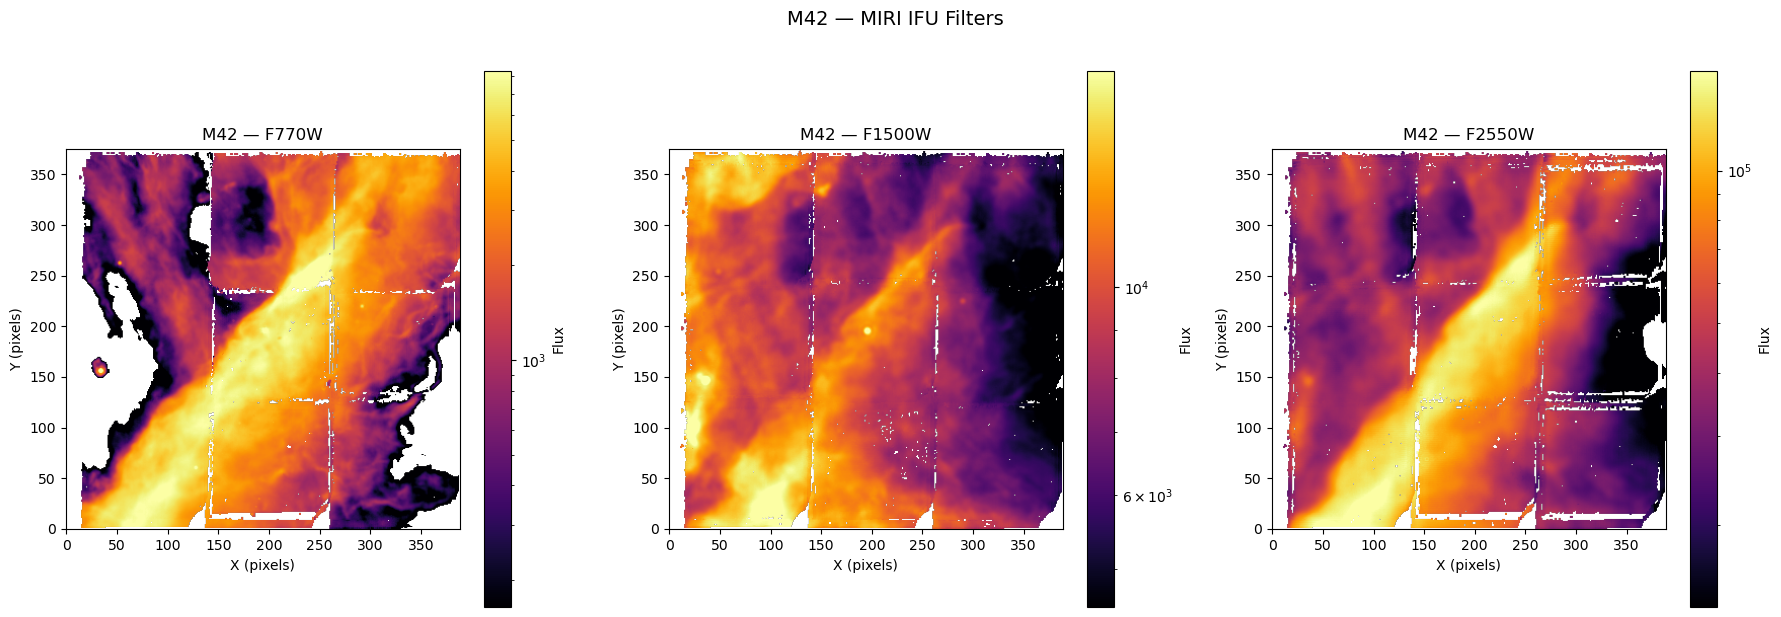

In [5]:
if len(all_filtered) == 0:
    print("Skipping plot: all_filtered is empty (no rows in your chosen filters).")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, f in enumerate(target_filters):
        filter_obs = all_filtered[all_filtered['filters'] == f]

        if len(filter_obs) == 0:
            print(f"No observations found for filter {f}, skipping...")
            continue

        dataURL = filter_obs[0]['dataURL']
        filename = dataURL.split("/")[-1]
        local_path = f"./fits_images/{target_name}/{filename}"

        if not os.path.exists(local_path):
            print(f"File not found for filter {f}: {local_path}")
            continue

        hdul = fits.open(local_path)

    # Try named extension first, fall back to index 1
        try:
            cube = hdul['SCI'].data
        except KeyError:
            cube = hdul[1].data

        cube = np.squeeze(cube)  # remove any size-1 dimensions

        if cube.ndim == 3:
            image = np.nansum(cube, axis=0)
        elif cube.ndim == 2:
            image = cube
        else:
            print(f"Cannot handle shape {cube.shape} for filter {f}, skipping...")
            hdul.close()
            continue

        # Replace non-positive values so LogNorm doesn't break
        image = np.where(image <= 0, np.nan, image)

        vmin = np.nanpercentile(image, 5)
        vmax = np.nanpercentile(image, 99)

        # Ensure vmin is positive for LogNorm
        vmin = max(vmin, 1e-10)
        if vmin >= vmax:
            vmax = vmin * 10  # fallback if image is nearly uniform

        ax = axes[i]
        im = ax.imshow(
            image,
            origin='lower',
            cmap='inferno',
            norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
        )
        ax.set_title(f"{target_name} — {f}", fontsize=12)
        ax.set_xlabel("X (pixels)")
        ax.set_ylabel("Y (pixels)")
        plt.colorbar(im, ax=ax, label="Flux")
        hdul.close()

    plt.suptitle(f"{target_name} — MIRI IFU Filters", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
